In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

## Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre process the data to apply the MLR

In [2]:
df = pd.read_csv("ToyotaCorolla - MLR.csv") #loading the dataset
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [3]:
print(df.shape)

(1436, 11)


In [4]:
df.rename(columns={'Age_08_04':'Age'},inplace = True) #rename the age column because Age_08_04 looks inappropriate

In [5]:
df.head()

,Price,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age        1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,1436.0,10730.824513,3626.964585,4350.0,8450.0,9900.0,11950.00,32500.0
Age,1436.0,55.947075,18.599988,1.0,44.0,61.0,70.00,80.0
KM,1436.0,68533.259749,37506.448872,1.0,43000.0,63389.5,87020.75,243000.0
HP,1436.0,101.502089,14.981080,69.0,90.0,110.0,110.00,192.0
Automatic,1436.0,0.055710,0.229441,0.0,0.0,0.0,0.00,1.0
cc,1436.0,1576.855850,424.386770,1300.0,1400.0,1600.0,1600.00,16000.0
Doors,1436.0,4.033426,0.952677,2.0,3.0,4.0,5.00,5.0
Cylinders,1436.0,4.000000,0.000000,4.0,4.0,4.0,4.00,4.0
Gears,1436.0,5.026462,0.188510,3.0,5.0,5.0,5.00,6.0
Weight,1436.0,1072.459610,52.641120,1000.0,1040.0,1070.0,1085.00,1615.0


In [8]:
df.isnull().sum()

Price        0
Age          0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df=df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

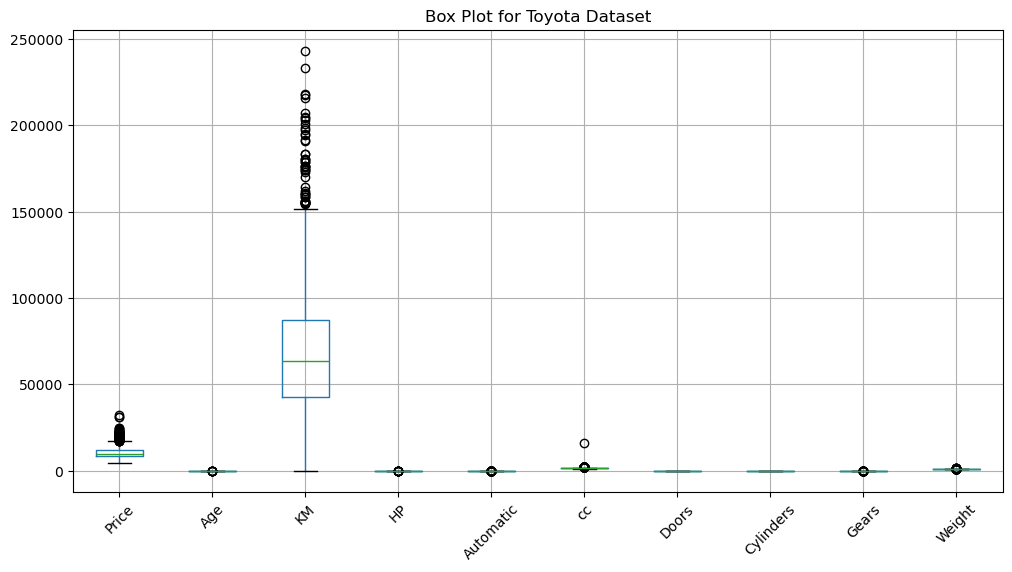

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
df[df.describe().columns].boxplot()
plt.title("Box Plot for Toyota Dataset")
plt.xticks(rotation=45)
plt.show()

From above we saw, "KM column" contains the max outliers in the column and next is "Price".

In [12]:
def outliers_detection(df): #Creating the function for detecting the outliers in the dataset
    outliers = pd.DataFrame() #Creating the dataframe to append the outliers
    for i in df.describe().columns:
        q1 = df[i].quantile(0.25) #Finding the first quantile of column
        q3 = df[i].quantile(0.75) #Finding the third quantile of column

        IQR = q3 - q1 #Finding the Interquartile range

        lower_bound = q1 - (1.5 * IQR) #finding the lower bound of column
        upper_bound = q3 + (1.5 * IQR) #finding the upper bound of column

        out = df[(df[i]<lower_bound) | (df[i]>upper_bound)] #Finding the outliers in the dataset
        outliers = pd.concat([outliers,out]) #Append the outliers to dataframe

    return outliers #Return the outliers from the dataset

In [13]:
outliers = outliers_detection(df)
df_outliers = outliers.drop_duplicates().reset_index().drop('index',axis=1)
df_outliers

,Price,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,18600,30,75889,Diesel,90,0,2000,3,4,5,1245
1,21500,27,19700,Petrol,192,0,1800,3,4,5,1185
2,20950,25,31461,Petrol,192,0,1800,3,4,6,1185
3,19950,22,43610,Petrol,192,0,1800,3,4,6,1185
4,19600,25,32189,Petrol,192,0,1800,3,4,6,1185
...,...,...,...,...,...,...,...,...,...,...,...
332,10450,65,36000,Petrol,110,0,1600,3,4,6,1065
333,10950,62,35512,Petrol,110,0,1600,3,4,6,1065
334,10750,60,31480,Petrol,110,0,1600,3,4,6,1065
335,12450,44,74172,Petrol,110,0,1600,5,4,5,1615


The detected outliers were removed from the dataset using the IQR method. This helps reduce the impact of extreme values on the regression model and improves model stability.

In [14]:
df.nunique()

Price         236
Age            77
KM           1263
Fuel_Type       3
HP             12
Automatic       2
cc             13
Doors           4
Cylinders       1
Gears           4
Weight         59
dtype: int64

In [15]:
df.drop(columns='Cylinders', inplace=True)
df.head()

,Price,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,5,1170


The Cylinders column contains only one unique value across all observations. Since it has no variability, it does not contribute to the regression model and was removed.

In [16]:
print(df.shape)

(1435, 10)


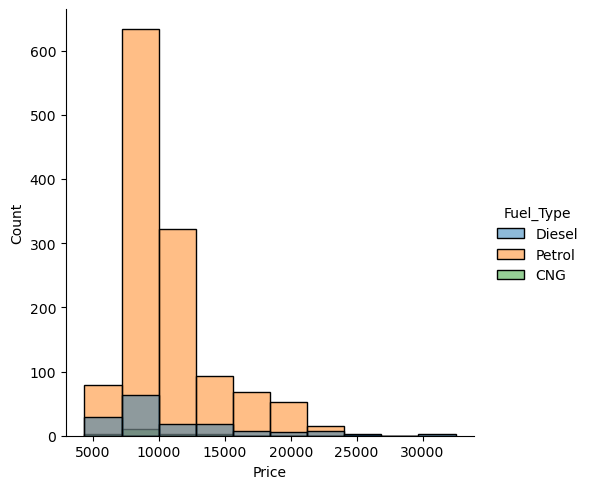

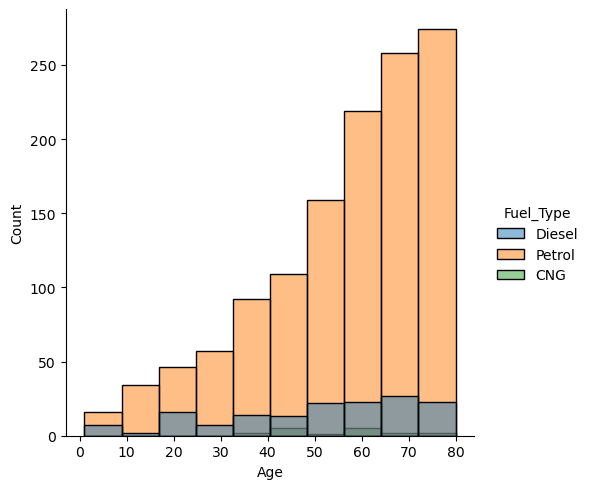

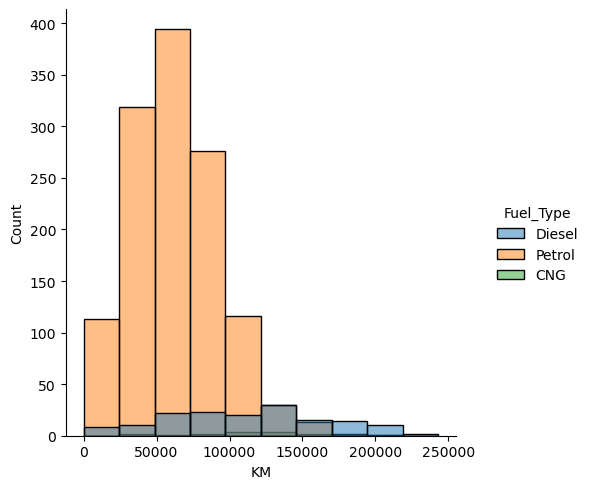

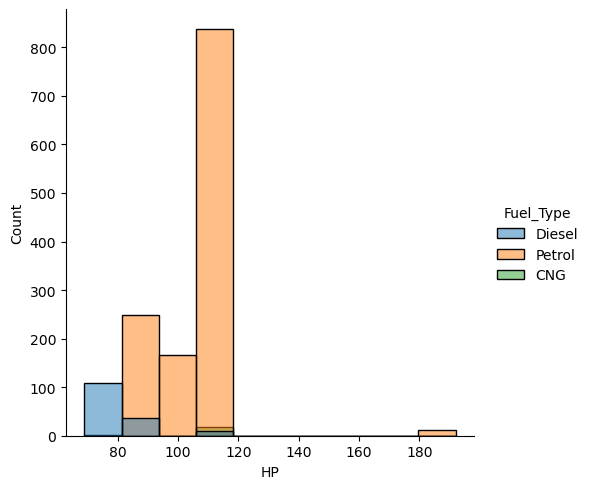

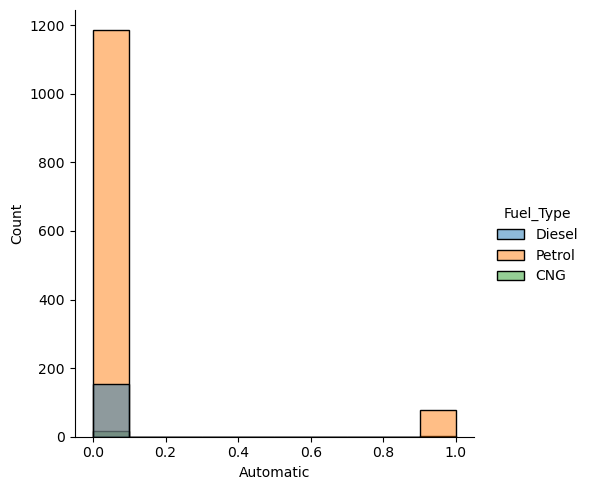

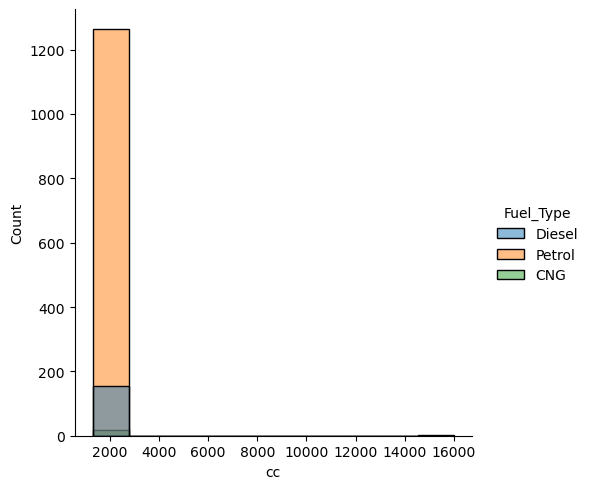

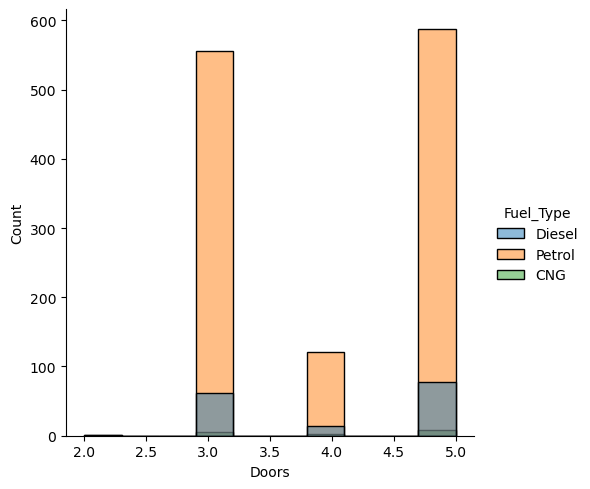

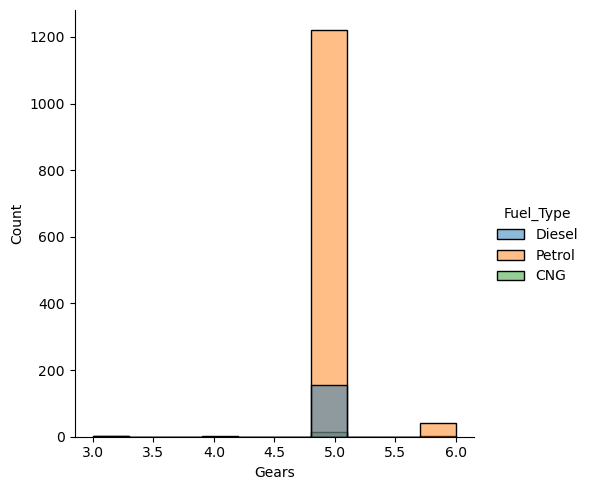

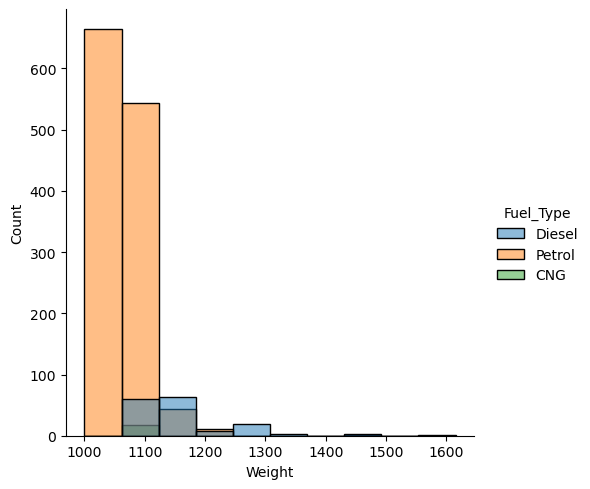

In [17]:
for i in df.describe().columns: #Ploting the histogram for numerical columns
    sns.displot(data=df,x=i,bins=10,hue='Fuel_Type')
    plt.show()

The histograms indicate that variables such as Price, KM, HP, Gears, and Weight are positively skewed, showing the presence of higher extreme values. Age is slightly negatively skewed, while Doors appears nearly symmetric. 

In [18]:
data = df['Fuel_Type'].value_counts().reset_index() #Counting number of cars in each fuel type to understand categorical distribution
data

,Fuel_Type,count
0,Petrol,1264
1,Diesel,154
2,CNG,17


- The dataset contains more Petrol cars compared to Diesel and CNG. 
- This indicates that Petrol vehicles dominate the dataset.

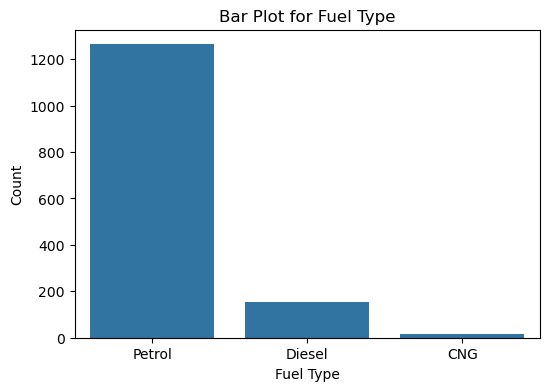

In [19]:
plt.figure(figsize=(6,4))
sns.barplot(data=data, x='Fuel_Type', y='count')
plt.title('Bar Plot for Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.show()

In [20]:
columns = df.describe().columns.drop('Automatic')
columns

Index(['Price', 'Age', 'KM', 'HP', 'cc', 'Doors', 'Gears', 'Weight'], dtype='object')

Removing Automatic from numeric columns because it is binary and should not be treated like continuous data.

In [21]:
corr = df[columns].corr() #Finding the correlation between numeric column
corr

,Price,Age,KM,HP,cc,Doors,Gears,Weight
Price,1.000000,-0.876273,-0.569420,0.314134,0.124375,0.183604,0.063831,0.575869
Age,-0.876273,1.000000,0.504575,-0.155293,-0.096549,-0.146929,-0.005629,-0.466484
KM,-0.569420,0.504575,1.000000,-0.332904,0.103822,-0.035193,0.014890,-0.023969
HP,0.314134,-0.155293,-0.332904,1.000000,0.035207,0.091803,0.209642,0.087143
cc,0.124375,-0.096549,0.103822,0.035207,1.000000,0.079254,0.014732,0.335077
Doors,0.183604,-0.146929,-0.035193,0.091803,0.079254,1.000000,-0.160101,0.301734
Gears,0.063831,-0.005629,0.014890,0.209642,0.014732,-0.160101,1.000000,0.021238
Weight,0.575869,-0.466484,-0.023969,0.087143,0.335077,0.301734,0.021238,1.000000


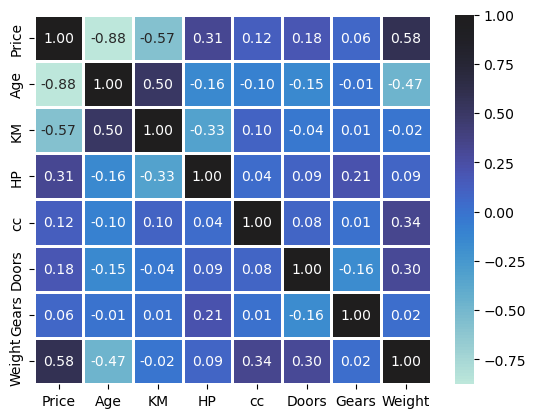

In [22]:
sns.heatmap(data=corr,annot=True,center=True,linecolor='white',linewidths=1,fmt=".2f") #Ploting the correlation matrix using seaborn heatmap
plt.show()

From the above correlation plot 

- The heatmap shows that Price has a strong negative correlation with Age and a moderate negative correlation with KM. 
- Weight has a moderate positive relationship with Price. No severe multi collinearity is observed among independent variables.

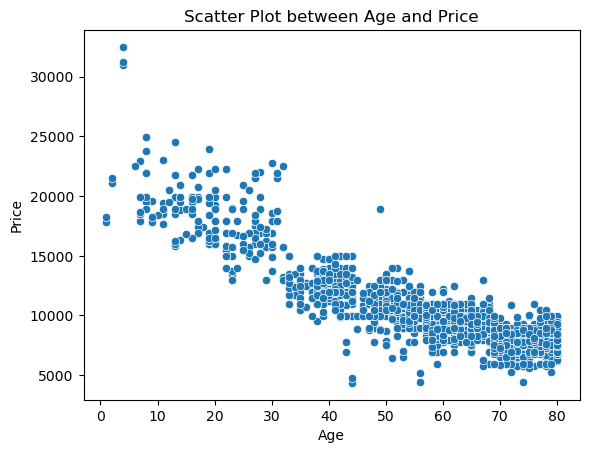

In [23]:
sns.scatterplot(data=df, x='Age', y='Price')
plt.title('Scatter Plot between Age and Price')
plt.show()

The scatter plot shows a strong negative relationship between Age and Price. As the age of the car increases, the price decreases.

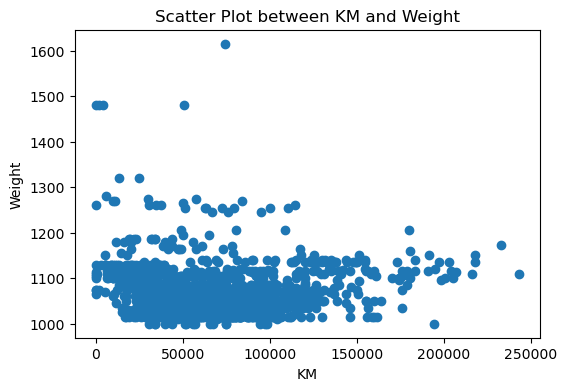

In [24]:
plt.figure(figsize=(6,4))
plt.scatter(df['KM'], df['Weight'])
plt.title('Scatter Plot between KM and Weight')
plt.xlabel('KM')
plt.ylabel('Weight')
plt.show()

- The scatter plot shows no clear linear relationship between KM and Weight.
- The points are randomly distributed, indicating very weak or no correlation between these variables.

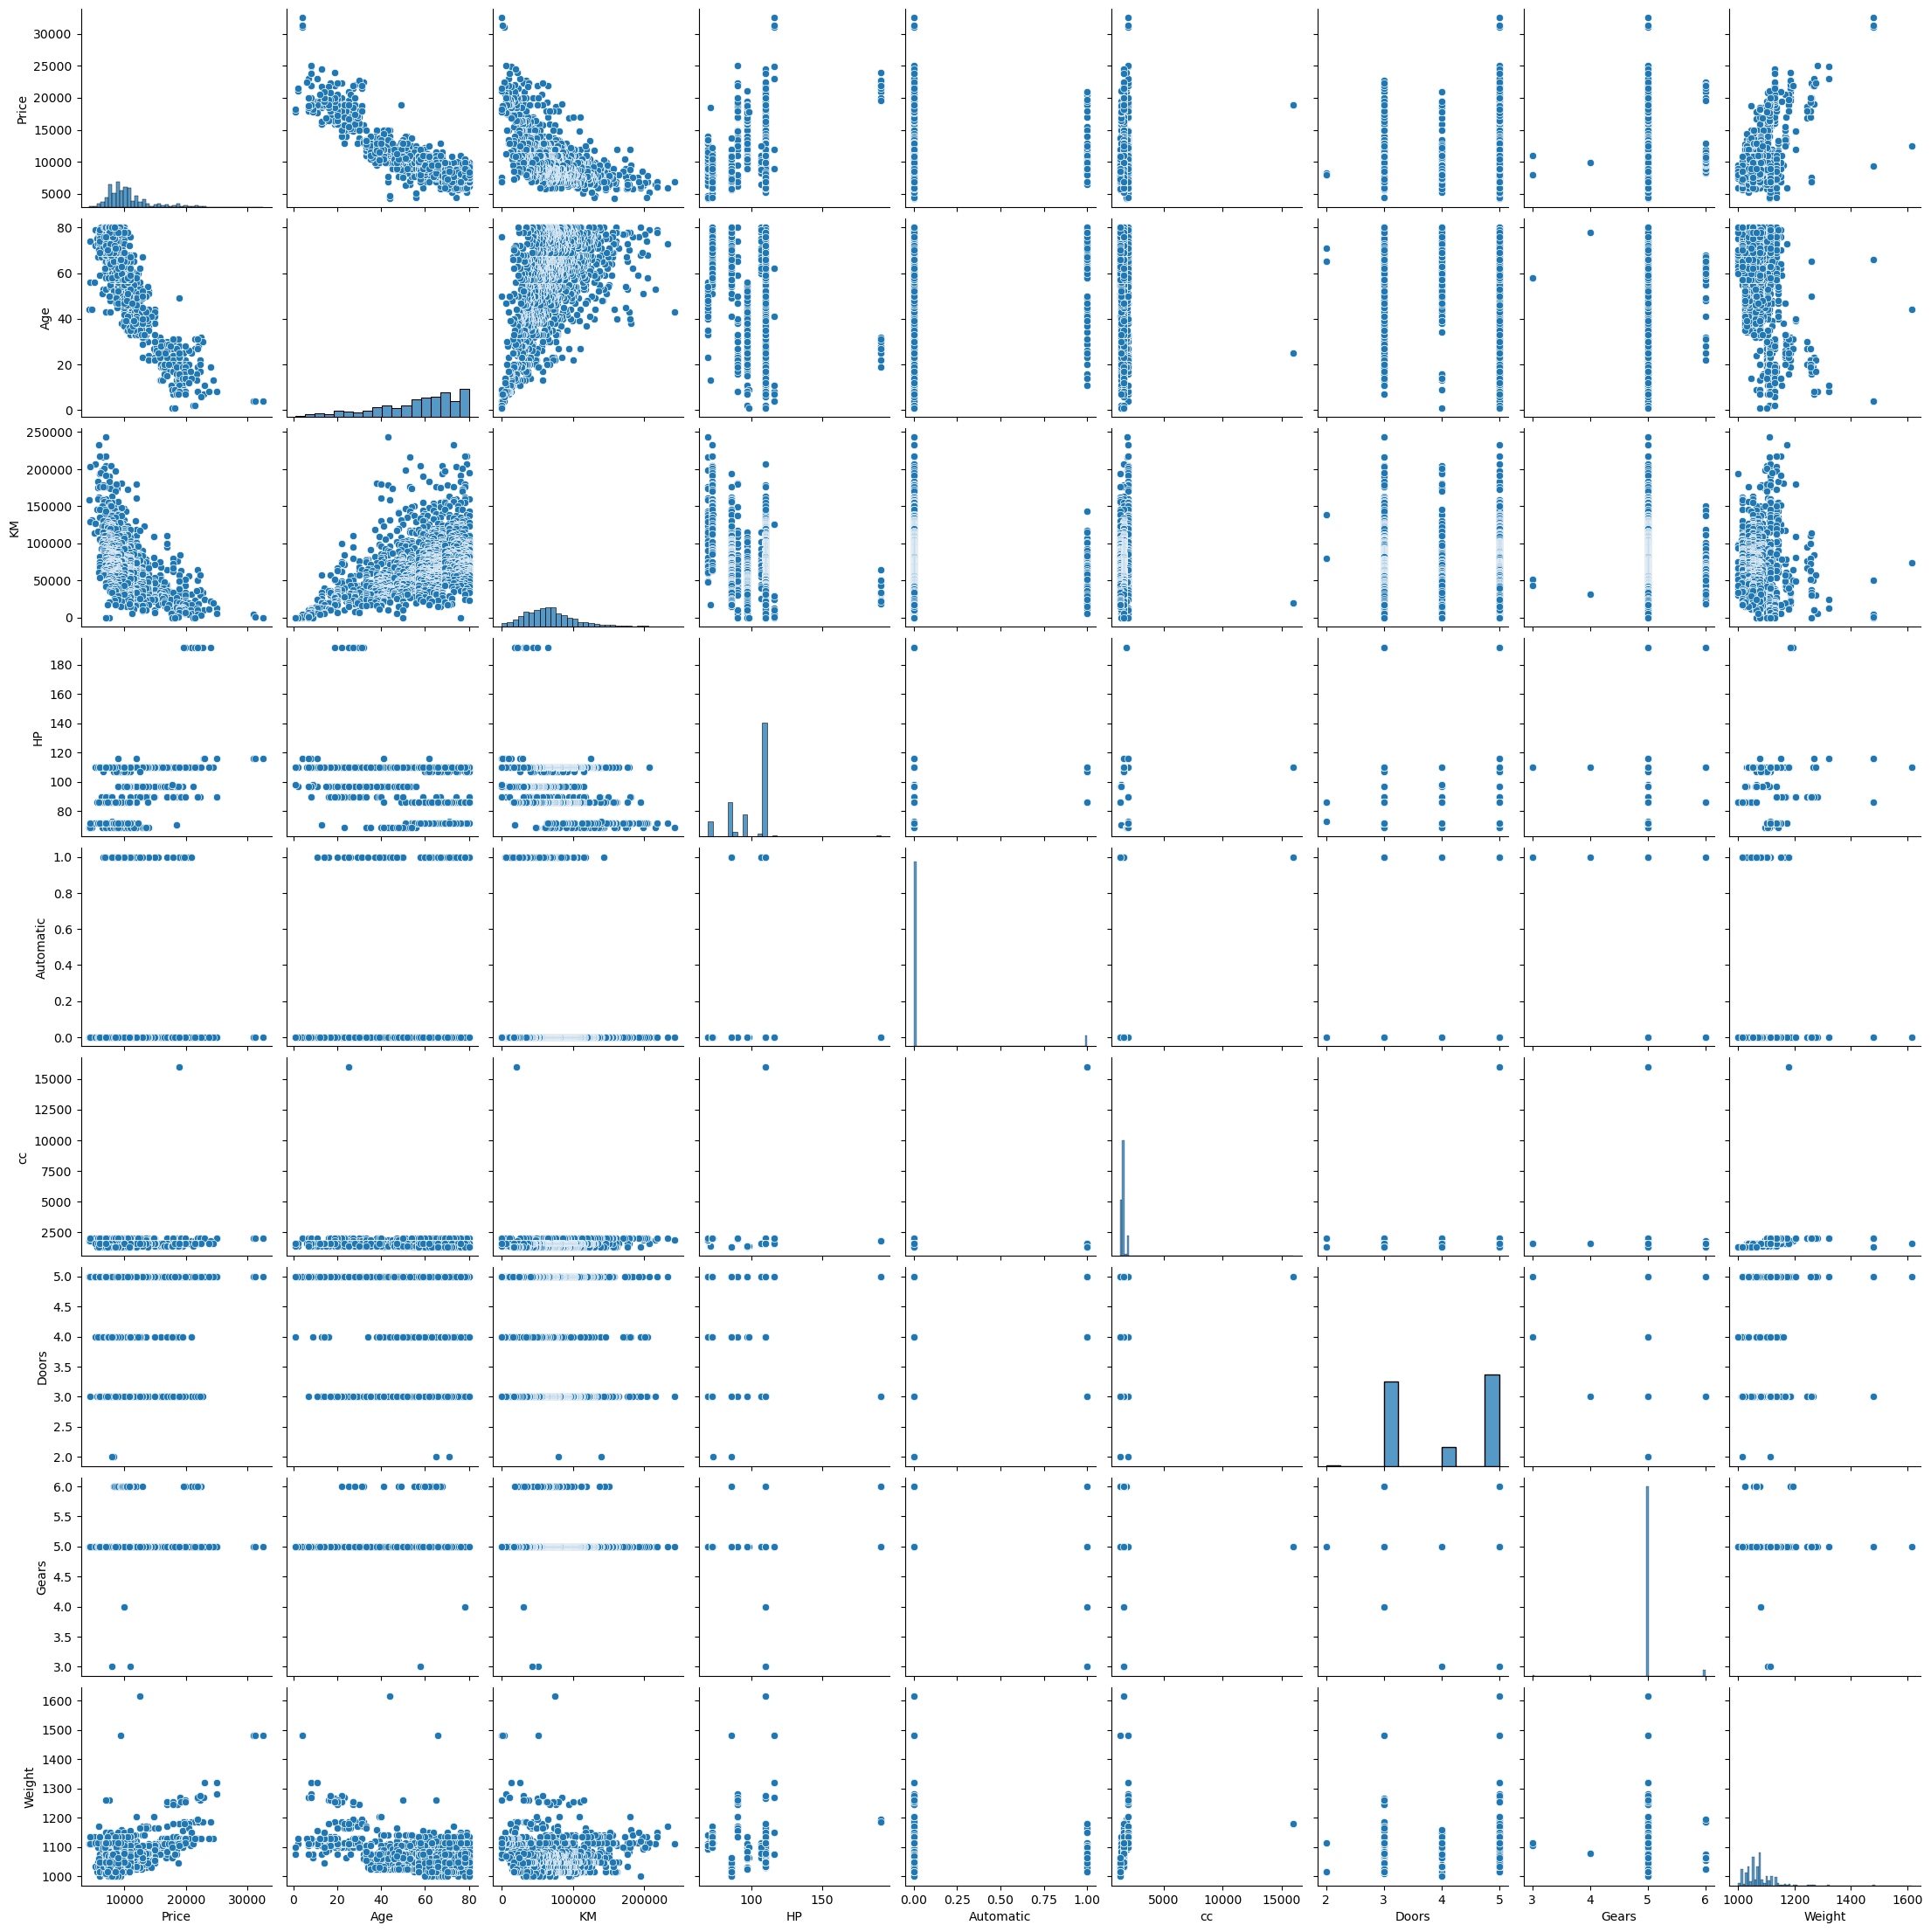

In [25]:
sns.pairplot(df[df.describe().columns]) #Ploting the pair plot for finding the correlation between each column in the dataset
plt.show()

- Age and KM are moderately correlated, meaning older cars usually have higher mileage. 
- Age and Weight show moderate negative correlation, while KM and Weight show very weak correlation.
- Since none of the correlations are very high, there is no serious multicollinearity problem among these variables.

In [26]:
df.columns

Index(['Price', 'Age', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc', 'Doors',
       'Gears', 'Weight'],
      dtype='object')

In [27]:
df.drop('Automatic', axis=1,inplace=True)
df.head()

,Price,Age,KM,Fuel_Type,HP,cc,Doors,Gears,Weight
0,13500,23,46986,Diesel,90,2000,3,5,1165
1,13750,23,72937,Diesel,90,2000,3,5,1165
2,13950,24,41711,Diesel,90,2000,3,5,1165
3,14950,26,48000,Diesel,90,2000,3,5,1165
4,13750,30,38500,Diesel,90,2000,3,5,1170


The 'Automatic' variable is removed from the dataset as it does not show a strong relationship with the target variable (Price) and is not expected to significantly improve the regression model.

In [28]:
Fuel = pd.get_dummies(df['Fuel_Type'],drop_first=True).astype(int) 
Fuel.head()

,Diesel,Petrol
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


- Dummy variables are created for the categorical variable 'Fuel_Type' to convert it into numerical format for regression analysis.
- The first category is dropped to avoid multi collinearity.

In [29]:
df = pd.concat([df,Fuel],axis=1) 
df

,Price,Age,KM,Fuel_Type,HP,cc,Doors,Gears,Weight,Diesel,Petrol
0,13500,23,46986,Diesel,90,2000,3,5,1165,1,0
1,13750,23,72937,Diesel,90,2000,3,5,1165,1,0
2,13950,24,41711,Diesel,90,2000,3,5,1165,1,0
3,14950,26,48000,Diesel,90,2000,3,5,1165,1,0
4,13750,30,38500,Diesel,90,2000,3,5,1170,1,0
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,1300,3,5,1025,0,1
1432,10845,72,19000,Petrol,86,1300,3,5,1015,0,1
1433,8500,71,17016,Petrol,86,1300,3,5,1015,0,1
1434,7250,70,16916,Petrol,86,1300,3,5,1015,0,1


In [30]:
df.drop('Fuel_Type', axis=1, inplace=True)
df.head()

,Price,Age,KM,HP,cc,Doors,Gears,Weight,Diesel,Petrol
0,13500,23,46986,90,2000,3,5,1165,1,0
1,13750,23,72937,90,2000,3,5,1165,1,0
2,13950,24,41711,90,2000,3,5,1165,1,0
3,14950,26,48000,90,2000,3,5,1165,1,0
4,13750,30,38500,90,2000,3,5,1170,1,0


In [31]:
df.columns

Index(['Price', 'Age', 'KM', 'HP', 'cc', 'Doors', 'Gears', 'Weight', 'Diesel',
       'Petrol'],
      dtype='object')

In [32]:
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split

In [33]:
Y = df['Price']

X1 = df.drop(columns=['Price','Weight','Age'])
X2 = df.drop(columns=['Price','KM','Age'])
X3 = df.drop(columns=['Price','KM','Weight'])

- The dependent variable (Price) is separated from the independent variables.
- Three different feature sets (X1, X2, X3) are created by removing different correlated variables (Age, KM, and Weight) to compare model performance and reduce multicollinearity.

## Split the dataset into training and testing sets .

In [34]:
X1_train, X1_test, Y1_train, Y1_test = train_test_split(X1, Y, test_size=0.2, random_state=42)
X2_train, X2_test, Y2_train, Y2_test = train_test_split(X2, Y, test_size=0.2, random_state=42)
X3_train, X3_test, Y3_train, Y3_test = train_test_split(X3, Y, test_size=0.2, random_state=42)

The dataset is split into training and testing sets (80% training and 20% testing) for each model to evaluate performance on unseen data.

In [35]:
print("Train Data :", X1_train.shape, Y1_train.shape)
print("Test Data :", X1_test.shape, Y1_test.shape)

Train Data : (1148, 7) (1148,)
Test Data : (287, 7) (287,)


## Build a multiple linear regression model using the training dataset.

In [36]:
model1 = LinearRegression()
model2 = LinearRegression()
model3 = LinearRegression()

Three Linear Regression models are initialized to train and compare different feature combinations.

In [37]:
model1.fit(X1_train, Y1_train)
model2.fit(X2_train, Y2_train)
model3.fit(X3_train, Y3_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
print(f"Intercept: {model1.intercept_}")

Intercept: 3581.3232567862906


In [39]:
for i, j in enumerate(X1.columns):
    print(f"The coefficient for {j} is {model1.coef_[i]}")

The coefficient for KM is -0.06460761742660062
The coefficient for HP is 78.34508181398117
The coefficient for cc is 0.1272866501296276
The coefficient for Doors is 444.9691386203732
The coefficient for Gears is 609.7589984006312
The coefficient for Diesel is 3569.5286393858746
The coefficient for Petrol is -2027.381954252503


**Interpretation of Beta Coefficients (Model 1)**

- KM has a negative impact on Price (higher KM reduces Price).
- HP, cc, Doors, and Gears have a positive impact on Price (increase in these increases Price).
- Diesel cars have higher Price compared to the base category.
- Petrol cars have lower Price compared to the base category.

In [40]:
print(f"Intercept: {model2.intercept_}") 

Intercept: -62887.04489397224


In [41]:
for i, j in enumerate(X2.columns):
    print(f"The coefficient for {j} is {model2.coef_[i]}")

The coefficient for HP is -7.143084540819627
The coefficient for cc is -0.1623289693920249
The coefficient for Doors is -340.6590518923558
The coefficient for Gears is 50.18699311031529
The coefficient for Weight is 67.84283410323454
The coefficient for Diesel is -2519.455567738215
The coefficient for Petrol is 3699.9215796393005


**Interpretation of Beta Coefficients (Model 2)**

- HP has a negative impact on Price (increase in HP slightly decreases Price).
- cc has a negative impact on Price.
- Doors has a negative impact on Price.
- Gears has a positive impact on Price.
- Weight has a positive impact on Price (heavier cars cost more).
- Diesel cars have lower Price compared to the base category.
- Petrol cars have higher Price compared to the base category.

In [42]:
print(f"Intercept: {model3.intercept_}") 

Intercept: 10141.437880262332


In [43]:
for i,j in enumerate(X3.columns): 
    print(f"The coefficient for {j} is {model3.coef_[i]}")

The coefficient for Age is -161.0952447152688
The coefficient for HP is 55.66581898682592
The coefficient for cc is 0.07627460200209613
The coefficient for Doors is 158.36852131206132
The coefficient for Gears is 337.44755741653387
The coefficient for Diesel is 2311.3060335256955
The coefficient for Petrol is 1388.8871191431085


**Interpretation of Beta Coefficients (Model 3)**

- Age has a negative impact on Price (older cars have lower Price).
- HP has a positive impact on Price.
- cc has a positive impact on Price.
- Doors has a positive impact on Price.
- Gears has a positive impact on Price.
- Diesel cars have higher Price compared to the base category.
- Petrol cars also have higher Price compared to the base category.

In [44]:
Y1_pred = model1.predict(X1_test)
Y2_pred = model2.predict(X2_test)
Y3_pred = model3.predict(X3_test)

## Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

#### Performance metrics for Model1

In [45]:
from sklearn import metrics

def adj_r2(y_test, y_pred, model, X_train):
    r2 = metrics.r2_score(y_test, y_pred)
    n = X_train.shape[0]        # number of observations
    p = X_train.shape[1]        # number of predictors
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

In [46]:
print("Model 1 Performance")

print("Mean Absolute Error:", metrics.mean_absolute_error(Y1_test, Y1_pred))
print("Mean Squared Error:", metrics.mean_squared_error(Y1_test, Y1_pred))
print("Root Mean Squared Error:", np.sqrt(metrics.mean_squared_error(Y1_test, Y1_pred)))
print("R_Squared:", metrics.r2_score(Y1_test, Y1_pred))
print("Adj R_Squared:", adj_r2(Y1_test, Y1_pred, model1, X1_train))

Model 1 Performance
Mean Absolute Error: 1856.2837736881363
Mean Squared Error: 5398040.803388582
Root Mean Squared Error: 2323.3684174896975
R_Squared: 0.5500557961541032
Adj R_Squared: 0.5472929808673301


#### Performance metrics for Model2

In [47]:
print("Model 2 Performance")

print("Mean Absolute Error:", metrics.mean_absolute_error(Y2_test, Y2_pred))
print("Mean Squared Error:", metrics.mean_squared_error(Y2_test, Y2_pred))
print("Root Mean Squared Error:", np.sqrt(metrics.mean_squared_error(Y2_test, Y2_pred)))
print("R_Squared:", metrics.r2_score(Y2_test, Y2_pred))
print("Adj R_Squared:", adj_r2(Y2_test, Y2_pred, model2, X2_train))

Model 2 Performance
Mean Absolute Error: 1972.3087333639241
Mean Squared Error: 9964960.37337913
Root Mean Squared Error: 3156.7325470142587
R_Squared: 0.16938824198190805
Adj R_Squared: 0.16428799434495478


#### Performance metrics for Model3

In [48]:
print("Model 3 Performance")

print("Mean Absolute Error:", metrics.mean_absolute_error(Y3_test, Y3_pred))
print("Mean Squared Error:", metrics.mean_squared_error(Y3_test, Y3_pred))
print("Root Mean Squared Error:", np.sqrt(metrics.mean_squared_error(Y3_test, Y3_pred)))
print("R_Squared:", metrics.r2_score(Y3_test, Y3_pred))
print("Adj R_Squared:", adj_r2(Y3_test, Y3_pred, model3, X3_train))

Model 3 Performance
Mean Absolute Error: 1114.498545913435
Mean Squared Error: 2266346.629998684
Root Mean Squared Error: 1505.4390157022915
R_Squared: 0.8110926598714369
Adj R_Squared: 0.8099327025197702


## Apply Lasso and Ridge methods on the model.

#### Ridge for Model1

In [49]:
from sklearn.linear_model import Ridge

ridgereg1 = Ridge(alpha=0.01)
ridgereg1.fit(X1_train, Y1_train)

y_pred = ridgereg1.predict(X1_test)

print("R_Squared:", metrics.r2_score(Y1_test, y_pred))
print("Adj R_Squared:", adj_r2(Y1_test, y_pred, ridgereg1, X1_train))

R_Squared: 0.5500469561266847
Adj R_Squared: 0.5472840865590416


#### Ridge for Model2

In [50]:
ridgereg2 = Ridge(alpha=0.01)
ridgereg2.fit(X2_train, Y2_train)

y_pred = ridgereg2.predict(X2_test)

print("R_Squared:", metrics.r2_score(Y2_test, y_pred))
print("Adj R_Squared:", adj_r2(Y2_test, y_pred, ridgereg2, X2_train))

R_Squared: 0.16942763600746835
Adj R_Squared: 0.1643276302636545


#### Ridge for Model3

In [51]:
ridgereg3 = Ridge(alpha=0.01)
ridgereg3.fit(X3_train, Y3_train)

y_pred = ridgereg3.predict(X3_test)

print("R_Squared:", metrics.r2_score(Y3_test, y_pred))
print("Adj R_Squared:", adj_r2(Y3_test, y_pred, ridgereg3, X3_train))

R_Squared: 0.8110845399837405
Adj R_Squared: 0.8099245327731144


#### Lasso for Model1

In [52]:
from sklearn.linear_model import Lasso

lassoreg1 = Lasso(alpha=0.01)
lassoreg1.fit(X1_train, Y1_train)

y_pred = lassoreg1.predict(X1_test)

print("R_Squared:", metrics.r2_score(Y1_test, y_pred))
print("Adj R_Squared:", adj_r2(Y1_test, y_pred, lassoreg1, X1_train))

R_Squared: 0.55005067798374
Adj R_Squared: 0.547287831269605


#### Lasso for Model2

In [53]:
lassoreg2 = Lasso(alpha=0.01)
lassoreg2.fit(X2_train, Y2_train)

y_pred = lassoreg2.predict(X2_test)

print("R_Squared:", metrics.r2_score(Y2_test, y_pred))
print("Adj R_Squared:", adj_r2(Y2_test, y_pred, lassoreg2, X2_train))

R_Squared: 0.16940571771628232
Adj R_Squared: 0.16430557738647


#### Lasso for Model3

In [54]:
lassoreg3 = Lasso(alpha=0.01)
lassoreg3.fit(X3_train, Y3_train)

y_pred = lassoreg3.predict(X3_test)

print("R_Squared:", metrics.r2_score(Y3_test, y_pred))
print("Adj R_Squared:", adj_r2(Y3_test, y_pred, lassoreg3, X3_train))

R_Squared: 0.8110873948941403
Adj R_Squared: 0.8099274052136657


## Conclusion

- Among the three models, **Model 3** performs the best with the highest R² (0.81) and lowest Root Mean Squared Error (RMSE). 
- Ridge and Lasso regression produced results similar to Linear Regression, indicating that regularization does not significantly improve the model.
- Therefore, **Model 3** using Linear Regression is selected as the final best model for predicting car Price.

### Interview Questions:
#### 1.What is Normalization & Standardization and how is it helpful?

- Normalization and Standardization are techniques used to scale numerical data so that all variables are on a similar range.
- Normalization transforms the data into a fixed range, usually 0 to 1. This is done by subtracting the minimum value and dividing by the range of the data.
- Standardization transforms the data so that it has a mean of 0 and a standard deviation of 1. It adjusts the values based on how far they are from the average.
- In Multiple Linear Regression, these techniques are helpful because the independent variables may have very different scales. For example, one variable may range from 0–1, while another may range from 0–10000. Scaling the data ensures that no variable dominates the model just because of its larger scale.
- Therefore, Normalization and Standardization help improve model performance, make coefficients easier to compare, and allow faster convergence during model training.

#### 2.What techniques can be used to address multicollinearity in multiple linear regression?

Some techniques to address multicollinearity in Multiple Linear Regression (MLR) are:

1. Remove highly correlated variables – If two independent variables are strongly correlated, one of them can be removed.
2. Use Variance Inflation Factor (VIF) – Detect variables with high multicollinearity and remove those with high VIF values.
3. Combine variables – Highly correlated variables can be combined into a single variable.
4. Apply Regularization methods – Techniques like Ridge Regression or Lasso Regression help reduce the effect of multicollinearity.
5. Increase sample size – Sometimes adding more data can reduce the impact of multicollinearity.